In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee, corner
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from matplotlib.patches import Patch

c:\Users\myswl\miniconda3\envs\ml\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
c:\Users\myswl\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


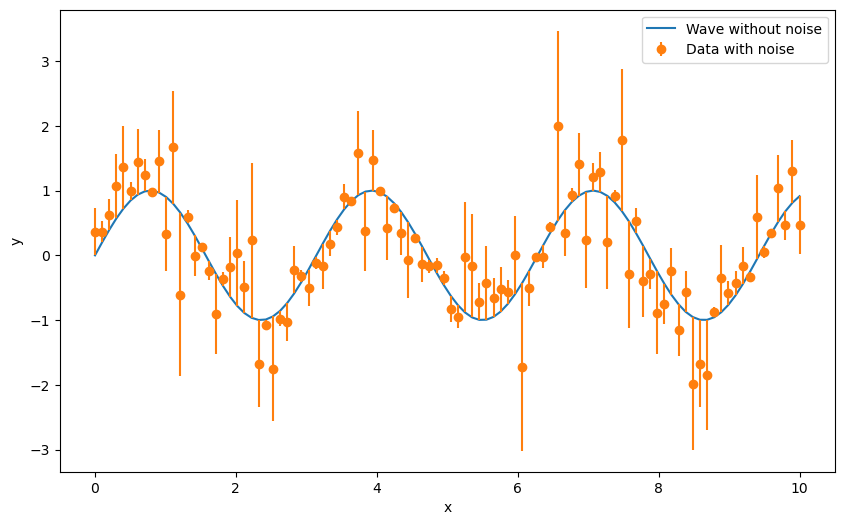

In [2]:
def simulate_wave(params):
    """Simulate a wave and add noise."""
    x = np.linspace(0, 10, 100)
    noise = 0.5 * np.random.normal(0, 1, size=x.shape)
    amplitude = params[0]
    omega = params[1]
    wave = amplitude * np.sin(omega * x) + noise
    return x, wave, noise

params = (1.0, 2.0)

points, w, n = simulate_wave(params)
plt.figure(figsize=(10, 6))
plt.plot(points, params[0]*np.sin(params[1] * points), label='Wave without noise')
plt.errorbar(points, w, yerr = np.sqrt(n*n), fmt='o', label='Data with noise')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

now the goal is to learn the true values of amplitude and frequency given noisy data points

In [54]:
"""
Wave Parameter Recovery with SBI — Class Implementation
===================================================================

Unified interface for recovering wave parameters using SBI/NPE.

NOISE MODEL: Sine wave with noise on datapoints:
  wave_obs = A * sin(ω * x) + ε,  ε ~ N(0, σ²)

Usage:
    study = WaveSBI(
        n_points=50,
        n_simulations=10000,
        noise_std=0.8
    )
    study.run_all()
"""

import numpy as np
import torch
import matplotlib.pyplot as plt
import emcee, corner
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from matplotlib.patches import Patch


class WaveSBI:
    """
    Unified interface for comparing MCMC and SBI/NPE on wave parameter recovery.
    
    Noise Model: wave_obs = A * sin(ω * x) + ε  (wave noise, constant measurement error)
    
    Attributes:
        n_points : int
            Number of measurement positions
        n_simulations : int
            Number of simulations for SBI training
        noise_std : float
            Standard deviation of wave measurement noise
        true_A : float
            True amplitude (units)
        true_omega : float
            True angular frequency (rad/s)
    """
    
    def __init__(self, n_points=50, n_simulations=10000, noise_std=0.8,
                 true_A=1.0, true_omega=2.0, seed=42, n_posterior=10000, nbins=10,
                 n_burn_in=1000, n_walkers=50):
        """
        Initialize the Wave Parameter Recovery study.
        
        Parameters:
        -----------
        n_points : int, default=50
            Number of measurement points (spatial positions)
        n_simulations : int, default=10000
            Number of simulations to generate for SBI training
        noise_std : float, default=0.8
            Standard deviation of wave measurement noise
        true_A : float, default=1.0
            True amplitude (units)
        true_omega : float, default=2.0
            True angular frequency (rad/s)
        seed : int, default=42
            Random seed for reproducibility
        n_posterior : int, default=5000
            Number of posterior samples to draw from SBI
        nbins : int, default=10
            Number of bins in which we divide the data
        """
        # Store parameters
        self.n_points = n_points
        self.n_simulations = n_simulations
        self.noise_std = noise_std
        self.true_A = true_A
        self.true_omega = true_omega
        self.seed = seed
        self.n_posterior = n_posterior
        self.nbins = nbins
        self.n_burn_in = n_burn_in
        self.n_walkers = n_walkers
        self.n_steps = int(n_posterior / n_walkers + n_burn_in)
    
        # Initialize random seeds
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        
        # Create measurement positions and observed data
        self.x_positions = np.linspace(-2.0, 2.0, n_points) # For all other parameters that changes the general model - could use a global dictionary that stores these parameters so that manual edits can come in at one singular point
        self.wave_observed = self._generate_observed_data()

        self.wave_observed_binned = self._bin_data(self.wave_observed, nbins)
        self.wave_noise_binned = self._bin_data(self.wave_noise, nbins)
        self.x_bins = self._bin_data(self.x_positions, nbins)   # bin positions too for plotting      
        
        # Results storage
        self.mcmc_samples = None
        self.sbi_samples_np = None
        self.A_mcmc = None
        self.omega_mcmc = None
        self.A_sbi = None
        self.omega_sbi = None
        self.posterior = None
    
    def _generate_observed_data(self):
        """
        Generate synthetic noisy wave measurements based on true parameters
        Model: wave_obs = A * sin(ω * x) + ε,  ε ~ N(0,1)
        """
        wave_clean = self.true_A * np.sin(self.true_omega * self.x_positions)
        self.wave_noise = self.rng.normal(0, self.noise_std, self.n_points)
        return wave_clean + self.wave_noise
    
    def _bin_data(self, y: np.ndarray, n_bins: int) -> np.ndarray:
        """
        Bin y into n_bins groups and return bin means.
        Uncertainty propagation is implicit: binning n points each with std σ
        gives a bin mean with std σ/√n — the simulator handles this automatically.
        """
        # Trim to make length divisible by n_bins
        n_trim = (len(y) // n_bins) * n_bins # What happens to the points that doesn't make it to the bin? Could possibly trim away meaningful data
        return y[:n_trim].reshape(n_bins, -1).mean(axis=1)   # shape: (n_bins,)

    def run_sbi(self, verbose=True):
        """
        Run SBI/NPE training and sample from posterior.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("SBI — Neural Posterior Estimation (NPE)")
            print("=" * 60)
        
        # Step 1: Define prior
        prior = sbi_utils.BoxUniform(
            low=torch.tensor([0.0, 0.0]),
            high=torch.tensor([5.0, 20.0])
        ) # Global dict
        
        # Step 2: Define simulator with WAVE NOISE model
        x_torch = torch.tensor(self.x_positions, dtype=torch.float32)
        
        def wave_simulator(theta):
            """
            Simulator for wave measurements.
            Model: y = A*sin(ω*x) + σ*ε,  ε ~ N(0,1)
            """
            if theta.dim() == 1:
                theta = theta.unsqueeze(0)
            
            A = theta[:, 0]
            omega = theta[:, 1]
            
            # wave_clean: (batch, n_points)
            # noise: (batch, n_points)
            # wave_obs: (batch, n_points)
            wave_clean = A.unsqueeze(1) * torch.sin(omega.unsqueeze(1) * x_torch.unsqueeze(0))
            noise = self.noise_std * torch.randn_like(wave_clean)
            wave_obs = wave_clean + noise


            # Bin each simulation the same way as the real data
            n_trim   = (self.n_points // self.nbins) * self.nbins
            wave_cut = wave_obs[:, :n_trim]          # (batch, n_trim)
            wave_bin = wave_cut.reshape(theta.shape[0], self.nbins, -1).mean(dim=2) # (batch, n_bins, pts_per_bin)
            
            return wave_bin
        
        # Step 3: Generate simulations
        if verbose:
            print(f"\nGenerating {self.n_simulations} simulations …")
        
        theta_sim, x_sim = simulate_for_sbi( # Python 3.9
            simulator = wave_simulator,
            proposal=prior,
            num_simulations=self.n_simulations,
        )
        if verbose:
            print(f"Simulated theta shape : {theta_sim.shape}")
            print(f"Simulated x shape     : {x_sim.shape}")
        
        # Step 4: Train neural density estimator
        if verbose:
            print("\nTraining NPE …")
        
        inference = NPE(prior=prior)
        density_estimator = inference.append_simulations(theta_sim, x_sim).train(show_train_summary=verbose)
        '''
        density_estimator = inference.train(
            training_batch_size=256,
            max_num_epochs=200,
            show_train_summary=verbose,
        )
        '''
        # Step 5: Build posterior and sample
        self.posterior = inference.build_posterior(density_estimator)
        x_obs_torch = torch.tensor(self.wave_observed_binned, dtype=torch.float32) # using binned now! (Training uses unbinned but posterior sampling uses binned data?)
        
        sbi_samples = self.posterior.sample(
            (self.n_posterior,),
            x=x_obs_torch,
        )
        self.sbi_samples_np = sbi_samples.numpy()
        self.A_sbi = np.median(self.sbi_samples_np[:, 0])
        self.omega_sbi = np.median(self.sbi_samples_np[:, 1])
        
        if verbose:
            print(f"\nSBI/NPE: A = {self.A_sbi:.3f},  omega = {self.omega_sbi:.3f}")
            print(f"         (true: {self.true_A}, {self.true_omega})\n")
    
    def run_lh(self, verbose=True):
        """
        Run likelihood-based training and sample from posterior.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("Likelihood-based — Markov Chain Monte Carlo (MCMC)")
            print("=" * 60)

        # Step 1: Define the model
        def simulate_model(theta):
            A, omega = theta[0], theta[1]
            y = A * np.sin(omega * self.x_positions)
            return self._bin_data(y,self.nbins)
        
        # Step 2: Define log-prior function
        def log_prior(theta):
            """
            Simple broad uniform priors for each parameter.
            """
            A, omega = theta
            if (0 < A < 5) and (0 < omega < 20):
                return 0.0  # log(0), impossible
            return -np.inf # log(1)
        
        # Step 3: Define log-likelihood function
        def log_likelihood(theta):
            """
            Assume:
            y_i = model(theta, x_i) + N(0, sigma^2), with fixed known sigma.
            This is equivalent to using the MSE in the exponent of the likelihood.
            """
            wave_simulated = simulate_model(theta)
            residuals = self.wave_observed_binned - wave_simulated
            mse = np.mean(residuals**2)  # mean squared error

            # For Gaussian errors with variance sigma^2, the log-likelihood is:
            # logL = -0.5 * sum[(residuals^2) / sigma^2 + log(2*pi*sigma^2)]
            #      = -N/2 * [ log(2*pi*sigma^2) + MSE/sigma^2 ]
            N = len(wave_simulated)
            return -0.5 * N * (np.log(2 * np.pi * self.wave_noise_binned**2) + mse / self.wave_noise_binned**2)

        def log_posterior(theta):
            lp = log_prior(theta)
            if not np.isfinite(lp):
                return -np.inf
            return lp + log_likelihood(theta)

        # Initialize walkers around a guess near the true parameters
        initial_guess = np.array([self.true_A, self.true_omega]) + 0.1 * np.random.randn(self.n_walkers, 2)

        sampler = emcee.EnsembleSampler(
            self.n_walkers, 2, log_posterior
        )

        print("Running MCMC...")
        self.mcmc_samples = sampler.run_mcmc(initial_state=initial_guess, nsteps=self.n_steps, progress=True)
    
    def plot_comparison(self, figsize=(15, 4)):
        print("\nPlotting …")
        x_line = np.linspace(self.x_positions.min(), self.x_positions.max(), 200)

        # ── 3-panel figure: predictive | P(A|data) | P(ω|data) ──────────────
        fig, axes = plt.subplots(1, 3, figsize=figsize)   # 1 row, not 2
        fig.suptitle("SBI (NPE) — Wave Parameter Recovery", fontsize=14)

        # (a) Posterior predictive
        ax = axes[0]
        pp_idx = self.rng.integers(self.n_posterior, size=200) # Pedantic: Could we not display all samples instead?
        for s in self.sbi_samples_np[pp_idx]:
            ax.plot(x_line, s[0] * np.sin(s[1] * x_line),   # FIX 1: np.sin, use both params
                    color="darkblue", alpha=0.05, lw=1)
        ax.errorbar(self.x_positions, self.wave_observed, yerr=np.abs(self.wave_noise), fmt = 'o', 
                color="darkblue", zorder=5, markersize=2,linestyle = 'none', label="Data") # Should swap colors of data and SBI line, also set zorder to set the order of each plot
        ax.plot(x_line, self.true_A * np.sin(self.true_omega * x_line),   # FIX 2: np.sin
                color="w",ls="--", lw=1.5, label=f"True A={self.true_A}, ω={self.true_omega}",zorder=10)
        ax.plot(x_line, self.A_sbi * np.sin(self.omega_sbi * x_line),
                "tomato", lw=1.5, label=f"SBI  A={self.A_sbi:.2f}, ω={self.omega_sbi:.2f}",zorder=20)
        ax.set(xlabel="Position (m)", ylabel="Amplitude", title="Posterior predictive")
        ax.legend(fontsize=8).set_zorder(30)

        # (b) Marginal posterior for A
        ax = axes[1]
        ax.hist(self.sbi_samples_np[:, 0], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_A, color="black", lw=2, ls="--", label=f"True A={self.true_A}")
        ax.axvline(self.A_sbi,  color="tomato", lw=2,          label=f"Median={self.A_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="A", ylabel="Density", title="P(A | data)")
        ax.legend(fontsize=8)

        # (c) Marginal posterior for ω
        ax = axes[2]
        ax.hist(self.sbi_samples_np[:, 1], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_omega, color="black", lw=2, ls="--", label=f"True ω={self.true_omega}")
        ax.axvline(self.omega_sbi,  color="tomato", lw=2,          label=f"Median={self.omega_sbi:.2f}")
        lo, hi = np.percentile(self.sbi_samples_np[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="ω (rad/s)", ylabel="Density", title="P(ω | data)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig("sbi_wave_results.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Corner plot: joint posterior P(A, ω | data) ──────────────────────
        fig2 = corner.corner(
            self.sbi_samples_np,
            labels=["A", "ω (rad/s)"],
            truths=[self.true_A, self.true_omega],
            truth_color="black",
            color="darkorange",
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
        )
        fig2.suptitle("Joint posterior  P(A, ω | data)", y=1.02, fontsize=13)
        plt.savefig("sbi_wave_corner.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("\n── Summary ─────────────────────────────────────────────")
        print(f"{'':10} {'A':>8} {'ω':>8}")
        print(f"{'True':10} {self.true_A:>8.3f} {self.true_omega:>8.3f}")
        print(f"{'SBI/NPE':10} {self.A_sbi:>8.3f} {self.omega_sbi:>8.3f}")


    def run_all(self, verbose=True):
        self.run_sbi(verbose=verbose)
        self.plot_comparison()          # FIX 4: removed non-existent print_summary()


#study = WaveSBI(n_points=300, n_simulations=10000, noise_std=0.3, true_A=1.0, true_omega=10.0, seed=42, n_posterior=10000)
#study.run_all()


In [90]:
class WaveMCMC:
    """
    Unified interface for comparing MCMC and SBI/NPE on wave parameter recovery.
    
    Noise Model: wave_obs = A * sin(ω * x) + ε  (wave noise, constant measurement error)
    
    Attributes:
        n_points : int
            Number of measurement positions
        n_simulations : int
            Number of simulations for SBI training
        noise_std : float
            Standard deviation of wave measurement noise
        true_A : float
            True amplitude (units)
        true_omega : float
            True angular frequency (rad/s)
    """
    
    def __init__(self, n_points=50, n_simulations=10000, noise_std=0.8,
                 true_A=1.0, true_omega=2.0, seed=42, n_posterior=10000, nbins=10,
                 n_burn_in=1000, n_walkers=50):
        """
        Initialize the Wave Parameter Recovery study.
        
        Parameters:
        -----------
        n_points : int, default=50
            Number of measurement points (spatial positions)
        n_simulations : int, default=10000
            Number of simulations to generate for SBI training
        noise_std : float, default=0.8
            Standard deviation of wave measurement noise
        true_A : float, default=1.0
            True amplitude (units)
        true_omega : float, default=2.0
            True angular frequency (rad/s)
        seed : int, default=42
            Random seed for reproducibility
        n_posterior : int, default=5000
            Number of posterior samples to draw from SBI
        nbins : int, default=10
            Number of bins in which we divide the data
        """
        # Store parameters
        self.n_points = n_points
        self.n_simulations = n_simulations
        self.noise_std = noise_std
        self.true_A = true_A
        self.true_omega = true_omega
        self.seed = seed
        self.n_posterior = n_posterior
        self.nbins = nbins
        self.n_burn_in = n_burn_in
        self.n_walkers = n_walkers
        self.n_steps = int(n_posterior / n_walkers + n_burn_in)
    
        # Initialize random seeds
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        
        # Create measurement positions and observed data
        self.x_positions = np.linspace(-2.0, 2.0, n_points) # For all other parameters that changes the general model - could use a global dictionary that stores these parameters so that manual edits can come in at one singular point
        self.wave_observed = self._generate_observed_data()

        self.wave_observed_binned = self._bin_data(self.wave_observed, nbins)
        self.wave_noise_binned = self._bin_data(self.wave_noise, nbins)
        self.x_bins = self._bin_data(self.x_positions, nbins)   # bin positions too for plotting      
        
        # Results storage
        self.mcmc_samples = None
        self.A_mcmc = None
        self.omega_mcmc = None
        self.sampler = None
    
    def _generate_observed_data(self):
        """
        Generate synthetic noisy wave measurements based on true parameters
        Model: wave_obs = A * sin(ω * x) + ε,  ε ~ N(0,1)
        """
        wave_clean = self.true_A * np.sin(self.true_omega * self.x_positions)
        self.wave_noise = self.rng.normal(0, self.noise_std, self.n_points)
        return wave_clean + self.wave_noise
    
    def _bin_data(self, y: np.ndarray, n_bins: int) -> np.ndarray:
        """
        Bin y into n_bins groups and return bin means.
        Uncertainty propagation is implicit: binning n points each with std σ
        gives a bin mean with std σ/√n — the simulator handles this automatically.
        """
        # Trim to make length divisible by n_bins
        n_trim = (len(y) // n_bins) * n_bins # What happens to the points that doesn't make it to the bin? Could possibly trim away meaningful data
        return y[:n_trim].reshape(n_bins, -1).mean(axis=1)   # shape: (n_bins,)
    
    def _plot_step_chain(self):
        if self.sampler is None:
            return
        _, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
        print(self.sampler)
        samples = self.sampler.get_chain()
        labels = ['A',r'$\omega$']
        for i in range(2):
            ax = axes[i]
            ax.plot(samples[:, :, i], "k", alpha=0.3)
            ax.set_xlim(0, len(samples))
            ax.set_ylabel(labels[i])
            ax.yaxis.set_label_coords(-0.1, 0.5)
        axes[-1].set_xlabel("step number")
        plt.show()

    def run_lh(self, verbose=True):
        """
        Run likelihood-based training and sample from posterior.
        
        Parameters:
        -----------
        verbose : bool, default=True
            Print progress and results
        """
        if verbose:
            print("=" * 60)
            print("Likelihood-based — Markov Chain Monte Carlo (MCMC)")
            print("=" * 60)

        # Step 1: Define the model
        def simulate_model(theta):
            A, omega = theta[0], theta[1]
            y = A * np.sin(omega * self.x_positions)
            return self._bin_data(y,self.nbins)
        
        # Step 2: Define log-prior function
        def log_prior(theta):
            """
            Simple broad uniform priors for each parameter.
            """
            A, omega = theta
            if (0 < A < 5) and (0 < omega < 20):
                return 0.0  # log(0), impossible
            return -np.inf # log(1)
        
        # Step 3: Define log-likelihood function
        def log_likelihood(theta):
            """
            Assume:
            y_i = model(theta, x_i) + N(0, sigma^2), with fixed known sigma.
            This is equivalent to using the MSE in the exponent of the likelihood.
            """
            wave_simulated = simulate_model(theta)
            residuals = self.wave_observed_binned - wave_simulated
            mse = np.mean(residuals**2)  # mean squared error

            # For Gaussian errors with variance sigma^2, the log-likelihood is:
            # logL = -0.5 * sum[(residuals^2) / sigma^2 + log(2*pi*sigma^2)]
            #      = -N/2 * [ log(2*pi*sigma^2) + MSE/sigma^2 ]
            N = len(wave_simulated)
            return -0.5 * N * (np.log(2 * np.pi * self.wave_noise_binned**2) + mse / self.wave_noise_binned**2)

        def log_posterior(theta):
            lp = log_prior(theta)
            if not np.isfinite(lp):
                return -np.inf
            return lp + log_likelihood(theta)

        # Initialize walkers around a guess near the true parameters
        initial_guess = np.array([self.true_A, self.true_omega]) + 0.1 * np.random.randn(self.n_walkers, 2)

        sampler = emcee.EnsembleSampler(
            self.n_walkers, 2, log_posterior
        )
        if verbose:
            print("Running MCMC...")
        sampler.run_mcmc(initial_state=initial_guess, nsteps=self.n_steps, progress=True)
        self.sampler = sampler

        self.mcmc_samples = sampler.get_chain(discard=self.n_burn_in,flat=True)
        self.A_mcmc = np.median(self.mcmc_samples[:, 0])
        self.omega_mcmc = np.median(self.mcmc_samples[:, 1])

        if verbose:
            print(f"\nMCMC: A = {self.A_mcmc:.3f},  omega = {self.omega_mcmc:.3f}")
            print(f" (true: {self.true_A}, {self.true_omega})\n")
    
    def plot_comparison(self, figsize=(15, 4)):
        print("\nPlotting …")
        x_line = np.linspace(self.x_positions.min(), self.x_positions.max(), 200)

        # ── 3-panel figure: predictive | P(A|data) | P(ω|data) ──────────────
        fig, axes = plt.subplots(1, 3, figsize=figsize)   # 1 row, not 2
        fig.suptitle("MCMC — Wave Parameter Recovery", fontsize=14)

        # (a) Posterior predictive
        ax = axes[0]
        pp_idx = self.rng.integers(self.n_posterior, size=200) # Pedantic: Could we not display all samples instead?
        for s in self.mcmc_samples[pp_idx]:
            ax.plot(x_line, s[0] * np.sin(s[1] * x_line),   # FIX 1: np.sin, use both params
                    color="darkblue", alpha=0.05, lw=1)
        ax.errorbar(self.x_positions, self.wave_observed, yerr=np.abs(self.wave_noise), fmt = 'o', 
                color="darkblue", zorder=5, markersize=2,linestyle = 'none', label="Data") # Should swap colors of data and SBI line, also set zorder to set the order of each plot
        ax.plot(x_line, self.true_A * np.sin(self.true_omega * x_line),   # FIX 2: np.sin
                color="k",ls="--", lw=1.5, label=f"True A={self.true_A}, ω={self.true_omega}",zorder=10)
        ax.plot(x_line, self.A_mcmc * np.sin(self.omega_mcmc * x_line),
                "tomato", lw=1.5, label=f"MCMC  A={self.A_mcmc:.2f}, ω={self.omega_mcmc:.2f}",zorder=20)
        ax.set(xlabel="Position (m)", ylabel="Amplitude", title="Posterior predictive")
        ax.legend(fontsize=8).set_zorder(30)

        # (b) Marginal posterior for A
        ax = axes[1]
        ax.hist(self.mcmc_samples[:, 0], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_A, color="black", lw=2, ls="--", label=f"True A={self.true_A}")
        ax.axvline(self.A_mcmc,  color="tomato", lw=2,          label=f"Median={self.A_mcmc:.2f}")
        lo, hi = np.percentile(self.mcmc_samples[:, 0], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="A", ylabel="Density", title="P(A | data)")
        ax.legend(fontsize=8)

        # (c) Marginal posterior for ω
        ax = axes[2]
        ax.hist(self.mcmc_samples[:, 1], bins=40, density=True,
                color="darkorange", alpha=0.7)
        ax.axvline(self.true_omega, color="black", lw=2, ls="--", label=f"True ω={self.true_omega}")
        ax.axvline(self.omega_mcmc,  color="tomato", lw=2,          label=f"Median={self.omega_mcmc:.2f}")
        lo, hi = np.percentile(self.mcmc_samples[:, 1], [16, 84])
        ax.axvspan(lo, hi, alpha=0.2, color="tomato", label="68% CI")
        ax.set(xlabel="ω (rad/s)", ylabel="Density", title="P(ω | data)")
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig("mcmc_wave_results.png", dpi=150, bbox_inches="tight")
        plt.show()

        # ── Corner plot: joint posterior P(A, ω | data) ──────────────────────
        fig2 = corner.corner(
            self.mcmc_samples,
            labels=["A", "ω (rad/s)"],
            truths=[self.true_A, self.true_omega],
            truth_color="black",
            color="darkorange",
            quantiles=[0.16, 0.5, 0.84],
            show_titles=True,
        )
        fig2.suptitle("Joint posterior  P(A, ω | data)", y=1.02, fontsize=13)
        plt.savefig("mcmc_wave_corner.png", dpi=150, bbox_inches="tight")
        plt.show()

        print("\n── Summary ─────────────────────────────────────────────")
        print(f"{'':10} {'A':>8} {'ω':>8}")
        print(f"{'True':10} {self.true_A:>8.3f} {self.true_omega:>8.3f}")
        print(f"{'MCMC':10} {self.A_mcmc:>8.3f} {self.omega_mcmc:>8.3f}")


    def run_all(self, verbose=True):
        self.run_lh(verbose=verbose)
        self.plot_comparison()          # FIX 4: removed non-existent print_summary()


#study = WaveSBI(n_points=300, n_simulations=10000, noise_std=0.3, true_A=1.0, true_omega=10.0, seed=42, n_posterior=10000)
#study.run_all()


okay let's try now to see how the SBI performs on binned data

100%|██████████| 100/100 [00:00<00:00, 12668.17it/s]


 Neural network successfully converged after 70 epochs.

10321it [00:00, 133777.76it/s]           



Plotting …


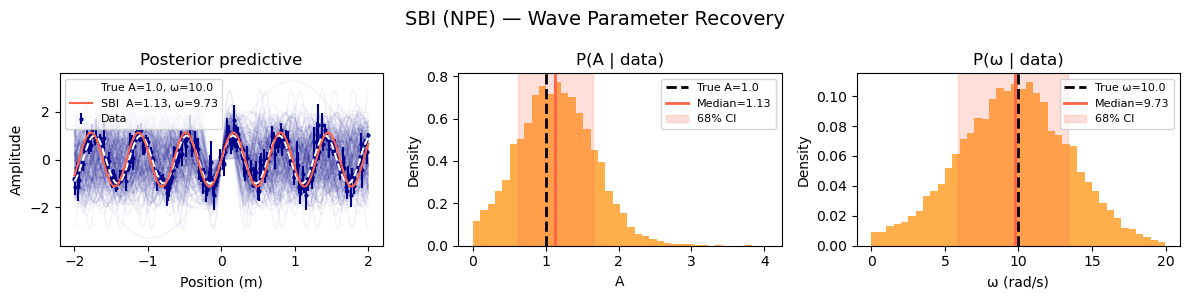

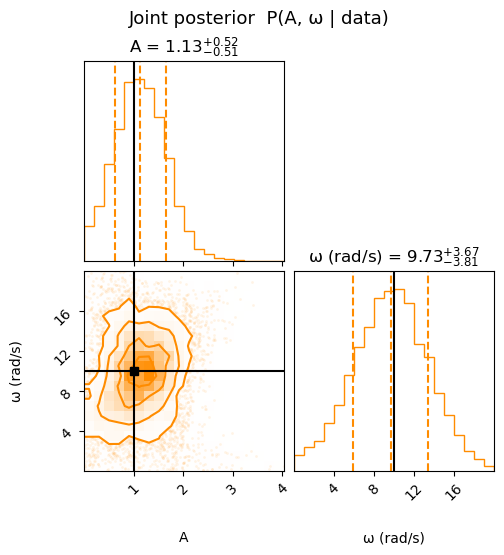


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       1.130    9.734
n_bins=100  |  σ(A)=1.030  σ(ω)=7.478


100%|██████████| 100/100 [00:00<00:00, 13317.79it/s]

 Training neural network. Epochs trained: 8

 Neural network successfully converged after 53 epochs.

10749it [00:00, 43592.62it/s]                          



Plotting …


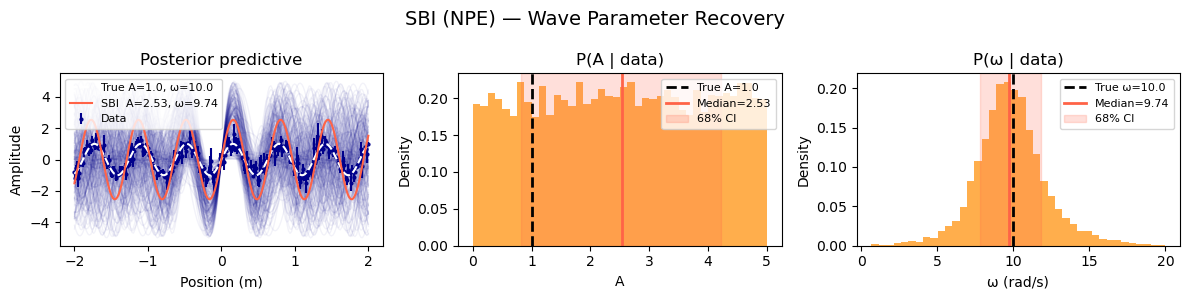

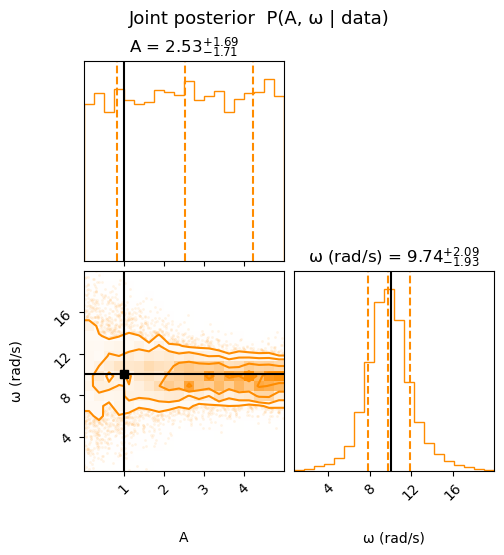


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       2.534    9.745
n_bins= 50  |  σ(A)=3.407  σ(ω)=4.019


100%|██████████| 100/100 [00:00<00:00, 12915.09it/s]

 Training neural network. Epochs trained: 8

 Neural network successfully converged after 77 epochs.

10242it [00:00, 159310.45it/s]           



Plotting …


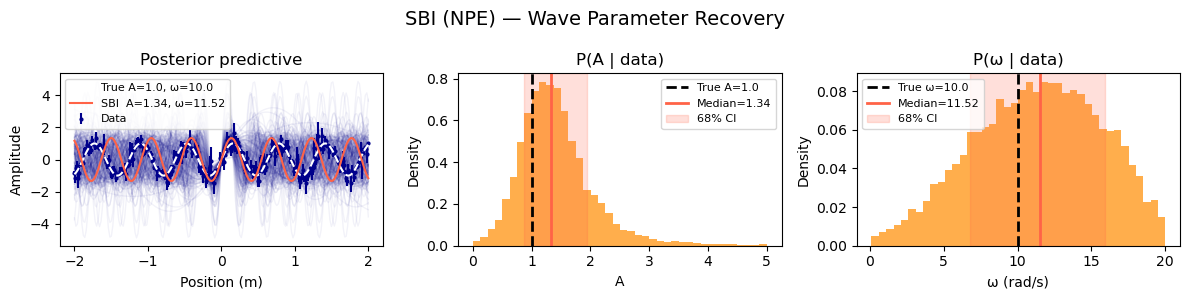

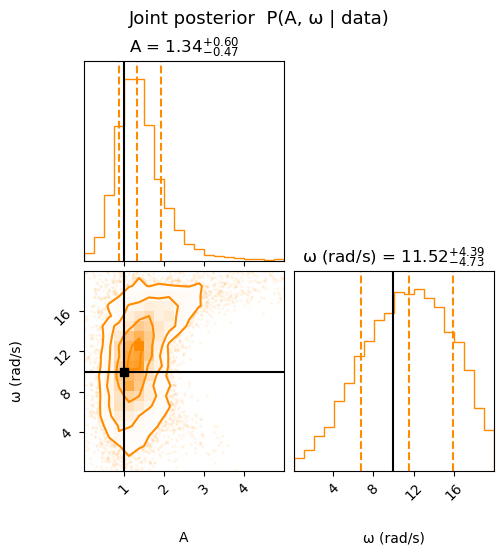


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       1.335   11.523
n_bins= 25  |  σ(A)=1.066  σ(ω)=9.122


100%|██████████| 100/100 [00:00<00:00, 13750.91it/s]

 Training neural network. Epochs trained: 9

 Neural network successfully converged after 119 epochs.

10426it [00:00, 173157.89it/s]           



Plotting …


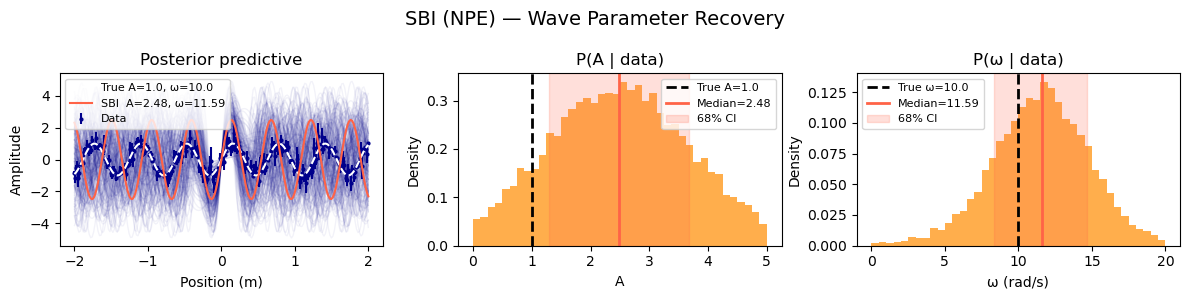

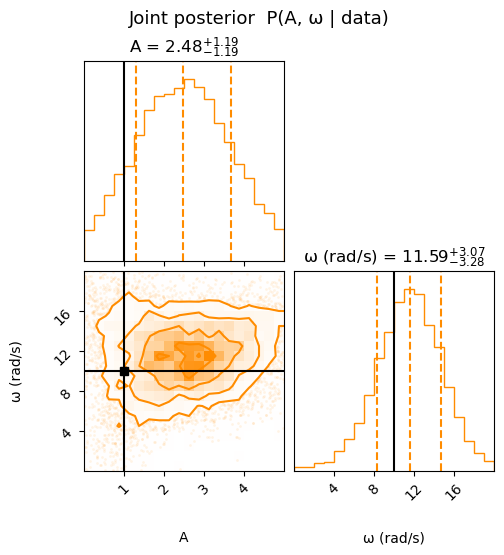


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
SBI/NPE       2.484   11.592
n_bins=  5  |  σ(A)=2.376  σ(ω)=6.352


In [88]:
results = {}
for n_bins in [100, 50, 25, 5]: # Should also include n_points = n_bins, so that we see the effect of unbinned data
    study = WaveSBI(n_points=300, n_simulations=100, # Personal observations: higher n_simulations (obviously) results in better fit, so we can increase it for final run
                    noise_std=0.3, true_A = 1.0, true_omega=10.0, seed = 42, n_posterior=10000, nbins=n_bins) #TODO: Have equal sampling in both SBI and MCMC for comparison
    study.run_sbi(verbose=False)
    study.plot_comparison(figsize=(12, 3))

    A_width = np.diff(np.percentile(study.sbi_samples_np[:, 0], [16, 84]))[0]
    w_width = np.diff(np.percentile(study.sbi_samples_np[:, 1], [16, 84]))[0]
    results[n_bins] = {"A_width": A_width, "omega_width": w_width}
    print(f"n_bins={n_bins:3d}  |  σ(A)={A_width:.3f}  σ(ω)={w_width:.3f}")

and try for MCMC for comparison:

Likelihood-based — Markov Chain Monte Carlo (MCMC)
Running MCMC...


100%|██████████| 1020/1020 [00:02<00:00, 476.55it/s]



MCMC: A = 0.967,  omega = 9.967
 (true: 1.0, 10.0)


Plotting …


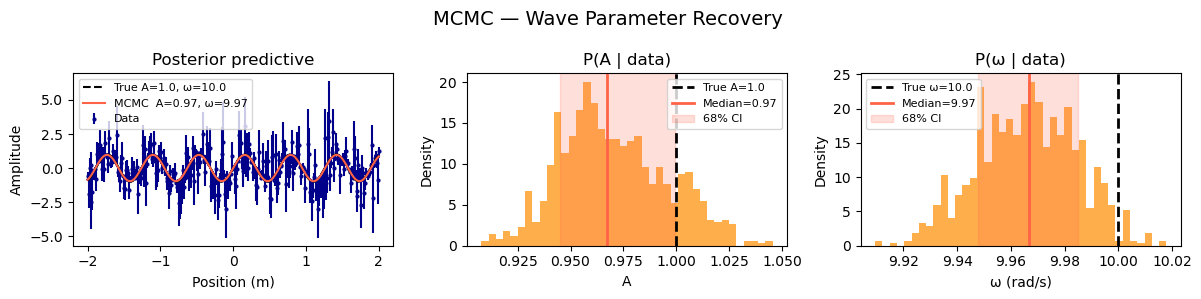

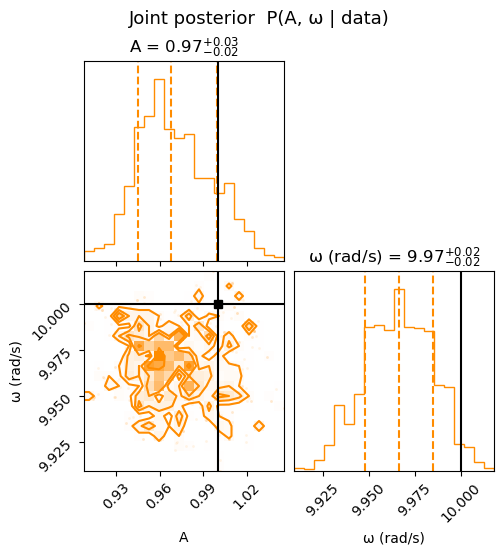


── Summary ─────────────────────────────────────────────
                  A        ω
True          1.000   10.000
MCMC          0.967    9.967


In [118]:
study = WaveMCMC(n_points=300, n_simulations=100,
                    noise_std=1, true_A = 1.0, true_omega=10.0, seed = 42, n_posterior=1000, nbins=300,
                    n_burn_in=1000,n_walkers=50)
study.run_lh()
study.plot_comparison(figsize=(12, 3))

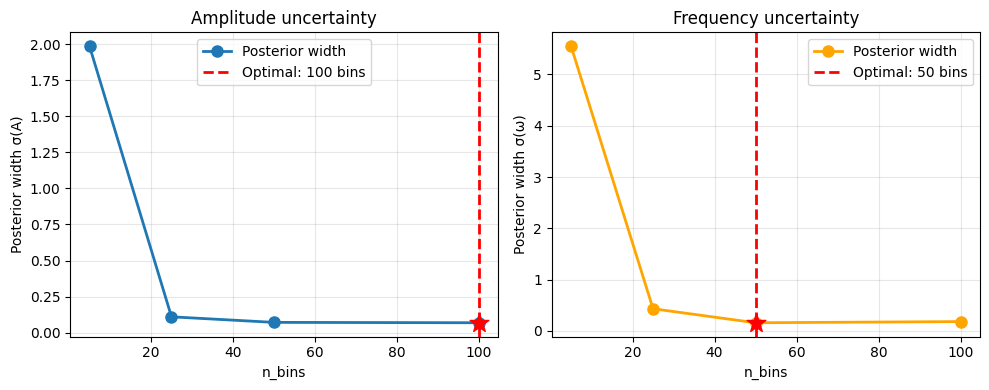

Optimal n_bins for A: 100  (width = 0.0688)
Optimal n_bins for ω: 50  (width = 0.1592)


In [ ]:
n_bins_list = sorted(results.keys())
A_widths = [results[nb]["A_width"] for nb in n_bins_list]
w_widths = [results[nb]["omega_width"] for nb in n_bins_list]

# Find optimal bins (minimum uncertainty)
optimal_A_idx = np.argmin(A_widths)
optimal_omega_idx = np.argmin(w_widths)
optimal_A_bins = n_bins_list[optimal_A_idx]
optimal_omega_bins = n_bins_list[optimal_omega_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot A uncertainty
ax1.plot(n_bins_list, A_widths, 'o-', lw=2, markersize=8, label="Posterior width")
ax1.axvline(optimal_A_bins, color='red', lw=2, ls='--', label=f"Optimal: {optimal_A_bins} bins")
ax1.scatter([optimal_A_bins], [A_widths[optimal_A_idx]], color='red', s=200, marker='*', zorder=5)
ax1.set(xlabel="n_bins", ylabel="Posterior width σ(A)", title="Amplitude uncertainty")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot ω uncertainty
ax2.plot(n_bins_list, w_widths, 'o-', lw=2, markersize=8, color="orange", label="Posterior width")
ax2.axvline(optimal_omega_bins, color='red', lw=2, ls='--', label=f"Optimal: {optimal_omega_bins} bins")
ax2.scatter([optimal_omega_bins], [w_widths[optimal_omega_idx]], color='red', s=200, marker='*', zorder=5)
ax2.set(xlabel="n_bins", ylabel="Posterior width σ(ω)", title="Frequency uncertainty")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Optimal n_bins for A: {optimal_A_bins}  (width = {A_widths[optimal_A_idx]:.4f})")
print(f"Optimal n_bins for ω: {optimal_omega_bins}  (width = {w_widths[optimal_omega_idx]:.4f})")
# I think it makes sense that you need less bins to infer omega because the noise over the data points affect
# the amplitude more. The frequency is largly uncorelated (?) with the noise because